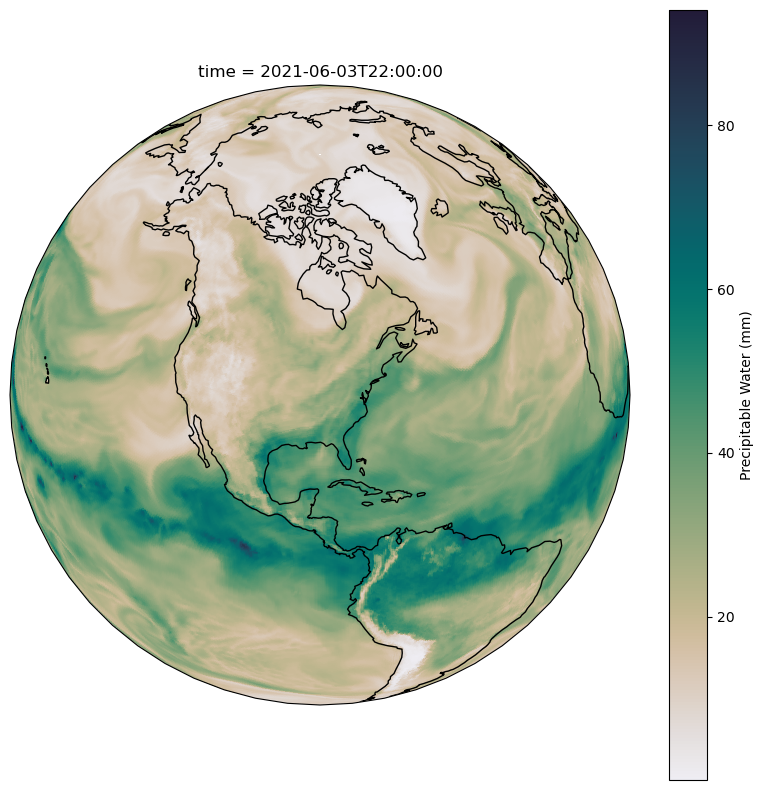

In [1]:
'''Use xarray to read in /N/project/easg690_fall2025/data/ERA5/ds633.0/e5.oper.an.sfc/202106/e5.oper.an.sfc.128_136_tcw.ll025sc.2021060100_2021063023.nc'''
import matplotlib.pyplot as plt
import cmocean
import cartopy
import cartopy.crs as ccrs
import os
import xarray as xr

TCW = f'/N/project/easg690_fall2025/data/ERA5/ds633.0/e5.oper.an.sfc/202106/e5.oper.an.sfc.128_136_tcw.ll025sc.2021060100_2021063023.nc'

tcw_Opened_File = xr.open_dataset(TCW, chunks = -1)
tcw_at_time_0 = tcw_Opened_File.isel(time=70)

# set the projection as frame of reference for figure
projection = ccrs.Orthographic(central_longitude=-86.5386, central_latitude=39.1696,globe=None)
plt.figure(figsize=(10, 10)) #creates figure and establishes its size
ax = plt.axes(projection=projection) #establishes axes as in relation to the projection just made


tcw_at_time_0['TCW'].plot(ax=ax, #georeferences the projection 
                          transform=ccrs.PlateCarree(), #establishes coordinate system
                          cmap=cmocean.cm.rain, #Maps data onto projection
                          cbar_kwargs={'label': 'Precipitable Water (mm)'} #labels colorbar
                          )#used chat gpt for this .plot call

ax.coastlines() #displays coastlines in reference to projection
plt.show()


In [2]:
def generate_frame(i,input_file,output_dir):
    
    plt.ioff()
    
    os.makedirs(output_dir, exist_ok=True)
    
    TCW = f'{input_file}' #reads in fine
    tcw_Opened_File = xr.open_dataset(TCW, chunks = -1) #opens file and assigns variable to data
    tcw_at_time_i = tcw_Opened_File.isel(time=i) #creates a variable for data at a specific timestep

    # set the projection as frame of reference for figure
    projection = ccrs.Orthographic(central_longitude=-86.5386, central_latitude=39.1696,globe=None)
    plt.figure(figsize=(10, 10)) #creates figure and establishes its size
    ax = plt.axes(projection=projection) #establishes axes as in relation to the projection just made

    tcw_at_time_i['TCW'].plot(ax=ax, #georeferences the projection 
                                        transform=ccrs.PlateCarree(), #establishes coordinate system
                                        cmap=cmocean.cm.rain, #Maps data onto projection
                                        cbar_kwargs={'label': 'Precipitable Water (mm)'} #labels colorbar
                                        )#used chat gpt for this .plot call

    ax.coastlines() #displays coastlines in reference to projection
    plt.savefig(f"{output_dir}/frame_{i:03d}.png",dpi=300,bbox_inches='tight') #Used chatgpt to assist in writing this line
    plt.close()
    

In [3]:
generate_frame(0,'/N/project/easg690_fall2025/data/ERA5/ds633.0/e5.oper.an.sfc/202106/e5.oper.an.sfc.128_136_tcw.ll025sc.2021060100_2021063023.nc', '/geode2/home/u015/bpgibbs/Quartz'
)

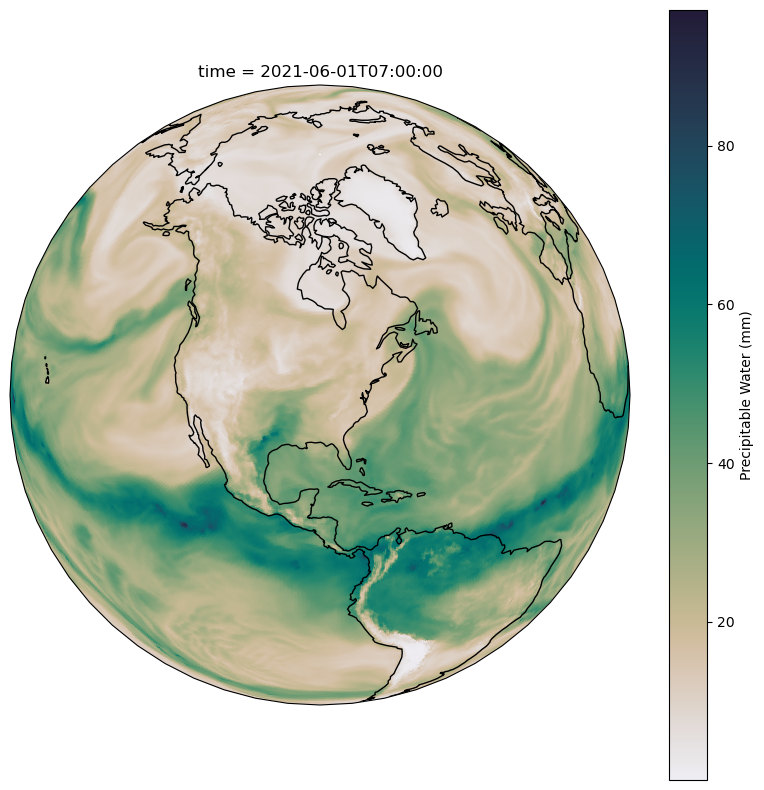

In [1]:
import generate_frame
generate_frame.generate_frame(7)